In [16]:
import matplotlib.pyplot as plt
from pprint import pprint
import spikeinterface

import spikeinterface as si  # import core only
import spikeinterface.extractors as se
import spikeinterface.preprocessing as spre
import spikeinterface.sorters as ss
import spikeinterface.postprocessing as spost
import spikeinterface.qualitymetrics as sqm
import spikeinterface.comparison as sc
import spikeinterface.exporters as sexp
import spikeinterface.curation as scur
import spikeinterface.widgets as sw

#and/or
import spikeinterface.full as si

from probeinterface import Probe, get_probe
from probeinterface.plotting import plot_probe

import numpy as np
import pandas as pd

In [17]:
# set global settings for processing
global_job_kwargs = dict(n_jobs=4, chunk_duration="1s")
si.set_global_job_kwargs(**global_job_kwargs)

In [18]:
oe_path = r'C:\Users\tmerri03\Desktop\Neural Data\60 Trial Data (click no puff)\unfiltered data'
recording = se.read_openephys(oe_path, stream_id='0')

In [19]:
channel_ids = recording.get_channel_ids()
fs = recording.get_sampling_frequency()
num_chan = recording.get_num_channels()
num_seg = recording.get_num_segments()

print("Channel ids:", channel_ids)
print("Sampling frequency:", fs)
print("Number of channels:", num_chan)
print("Number of segments:", num_seg)

Channel ids: ['CH1' 'CH2' 'CH3' 'CH4' 'CH5' 'CH6' 'CH7' 'CH8' 'CH9' 'CH10' 'CH11'
 'CH12' 'CH13' 'CH14' 'CH15' 'CH16' 'CH17' 'CH18' 'CH19' 'CH20' 'CH21'
 'CH22' 'CH23' 'CH24' 'CH25' 'CH26' 'CH27' 'CH28' 'CH29' 'CH30' 'CH31'
 'CH32']
Sampling frequency: 30000.0
Number of channels: 32
Number of segments: 1


(<matplotlib.collections.PolyCollection at 0x19f74b18140>,
 <matplotlib.collections.PolyCollection at 0x19f74b06bd0>)

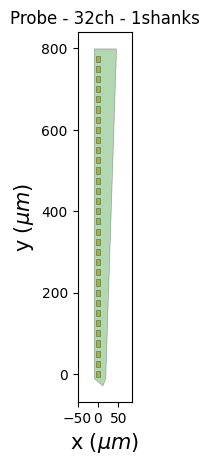

In [20]:
chan_map = [
    29, 19, 18, 28, 30, 20, 17, 21,
    31, 22, 16, 23, 27, 26, 25, 24,
    7, 6, 5, 4, 8, 10, 9, 3,
    11, 2, 12, 1, 13, 0, 14, 15
]
my_probe = get_probe(manufacturer="cambridgeneurotech", probe_name="ASSY-37-H4")
my_probe.set_device_channel_indices(chan_map)
recording_P1 = recording.set_probe(my_probe, group_mode='by_shank')
plot_probe(recording_P1.get_probe())

In [21]:
recording_cmr = recording_P1
recording_f = si.bandpass_filter(recording_P1, freq_min=300, freq_max=10000)
print(recording_f)
recording_cmr = si.common_reference(recording_f, reference="global", operator="median")
print(recording_cmr)
recording_preprocessed = recording_cmr.save(format="binary")
print(recording_preprocessed)

BandpassFilterRecording: 32 channels - 30.0kHz - 1 segments - 279,397,500 samples 
                         9,313.25s (2.59 hours) - int16 dtype - 16.65 GiB
CommonReferenceRecording: 32 channels - 30.0kHz - 1 segments - 279,397,500 samples 
                          9,313.25s (2.59 hours) - int16 dtype - 16.65 GiB
Use cache_folder=C:\Users\tmerri03\AppData\Local\Temp\spikeinterface_cache\tmp7cfbnc2h\6QWPYDAC
write_binary_recording 
engine=process - n_jobs=4 - samples_per_chunk=30,000 - chunk_memory=1.83 MiB - total_memory=7.32 MiB - chunk_duration=1.00s


write_binary_recording (workers: 4 processes): 100%|██████████| 9314/9314 [01:42<00:00, 90.88it/s]


BinaryFolderRecording: 32 channels - 30.0kHz - 1 segments - 279,397,500 samples 
                       9,313.25s (2.59 hours) - int16 dtype - 16.65 GiB


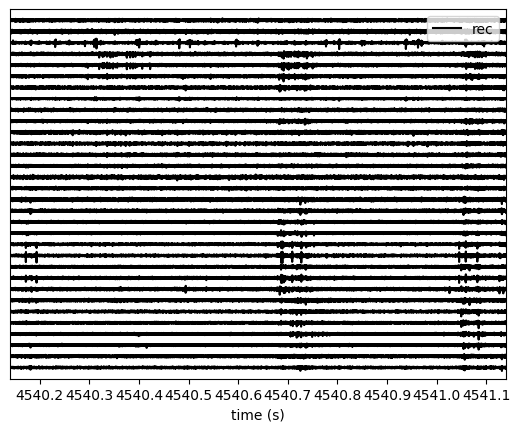

In [22]:
sw.plot_traces(recording_preprocessed)

In [23]:
print("Available sorters", ss.available_sorters())
print("Installed sorters", ss.installed_sorters())

print("kilosort4 parameters:")
pprint(ss.get_default_sorter_params("kilosort4"))

Available sorters ['combinato', 'hdsort', 'herdingspikes', 'ironclust', 'kilosort', 'kilosort2', 'kilosort2_5', 'kilosort3', 'kilosort4', 'mountainsort4', 'mountainsort5', 'pykilosort', 'rtsort', 'simple', 'spykingcircus', 'spykingcircus2', 'tridesclous', 'tridesclous2', 'waveclus', 'waveclus_snippets', 'yass']
Installed sorters ['kilosort4', 'simple', 'spykingcircus2', 'tridesclous2']
kilosort4 parameters:
{'Th_learned': 8,
 'Th_single_ch': 6,
 'Th_universal': 9,
 'acg_threshold': 0.2,
 'artifact_threshold': inf,
 'bad_channels': None,
 'batch_downsampling': 1,
 'batch_size': 60000,
 'binning_depth': 5,
 'ccg_threshold': 0.25,
 'chunk_duration': '1s',
 'clear_cache': False,
 'cluster_downsampling': 20,
 'cluster_init_seed': 5,
 'cluster_neighbors': 10,
 'delete_recording_dat': True,
 'dmin': None,
 'dminx': 32,
 'do_CAR': True,
 'do_correction': True,
 'drift_smoothing': [0.5, 0.5, 0.5],
 'duplicate_spike_ms': 0.25,
 'highpass_cutoff': 300,
 'invert_sign': False,
 'keep_good_only': Fa

In [24]:
sorting_out_folder = r'C:\Users\tmerri03\Desktop\Neural Data\60 Trial Data (click no puff)\unfiltered data\test\sorting_TDC'
sorting_TDC = ss.run_sorter(sorter_name="kilosort4", recording=recording_preprocessed, folder = sorting_out_folder) #add any param changes as arguments to the call
print(sorting_TDC)


100%|██████████| 1/1 [01:13<00:00, 73.74s/it]


KiloSortSortingExtractor: 48 units - 1 segments - 30.0kHz


In [25]:
out_folder = r'C:\Users\tmerri03\Desktop\Neural Data\60 Trial Data (click no puff)\unfiltered data\test\analyzer_TDC_binary'
analyzer_TDC = si.create_sorting_analyzer(sorting=sorting_TDC, recording=recording_preprocessed, format='binary_folder', folder=out_folder)
# analyzer_TDC.compute("random_spikes")
# analyzer_TDC.compute("waveforms")
# analyzer_TDC.compute("noise_levels")
# analyzer_TDC.compute("templates")
# analyzer_TDC.compute("spike_amplitudes")

estimate_sparsity (workers: 4 processes): 100%|██████████| 9314/9314 [00:03<00:00, 2504.12it/s]
C:\Users\tmerri03\AppData\Local\miniconda3\envs\SpikeSorting\Lib\site-packages\spikeinterface\core\basesorting.py:380: UserWarning: The registered recording will not be persistent on disk, but only available in memory
  warnings.warn("The registered recording will not be persistent on disk, but only available in memory")


In [26]:
# print(analyzer_TDC)
#
# from spikeinterface_gui import run_mainwindow
# sorting_analyzer = si.load_sorting_analyzer(out_folder)
# # open and run the Qt app
# run_mainwindow(sorting_analyzer, mode="desktop", curation=True)

SortingAnalyzer: 32 channels - 48 units - 1 segments - binary_folder - sparse - has recording
Loaded 0 extensions


AssertionError: 

In [27]:
extensions_to_compute = [
    "random_spikes",
    "waveforms",
    "noise_levels",
    "templates",
    "spike_amplitudes",
    "unit_locations",
    "spike_locations",
    "correlograms",
    "template_similarity"
]

extension_params = {
    "unit_locations": {"method": "center_of_mass"},
    "spike_locations": {"ms_before": 0.1},
    "correlograms": {"bin_ms": 0.1},
    "template_similarity": {"method": "cosine_similarity"}
}

analyzer_TDC.compute(extensions_to_compute, extension_params=extension_params)

noise_level (workers: 4 processes): 100%|██████████| 20/20 [00:00<00:00, 65.96it/s]
Compute : spike_amplitudes + spike_locations (workers: 4 processes): 100%|██████████| 9314/9314 [00:28<00:00, 322.29it/s]


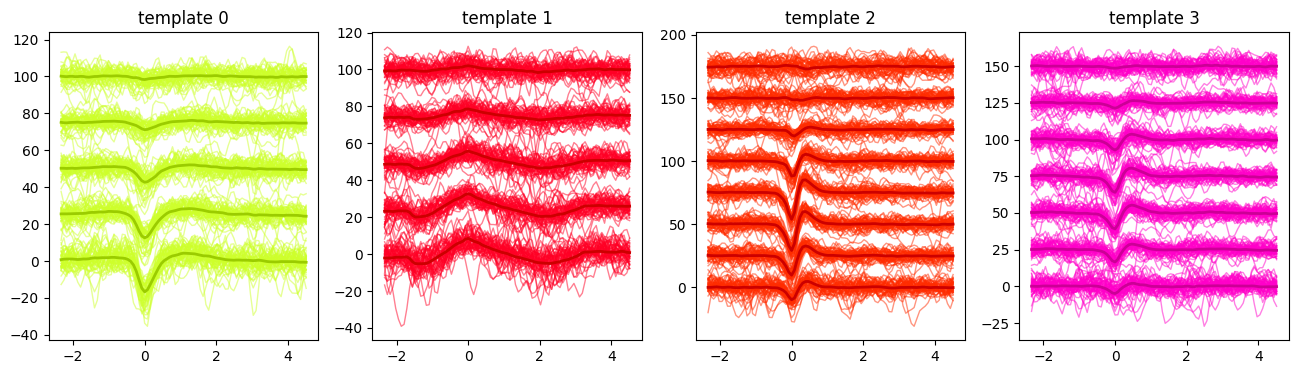

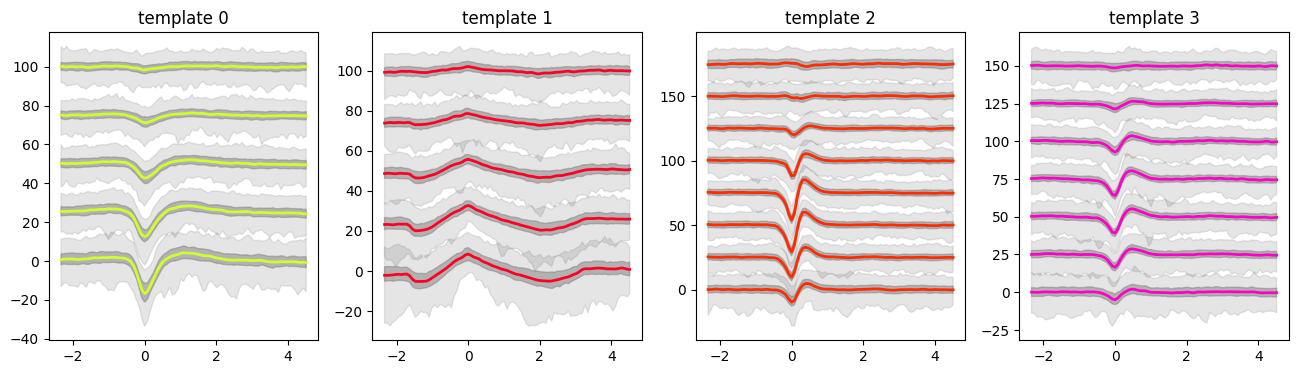

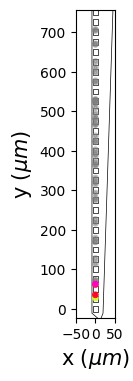

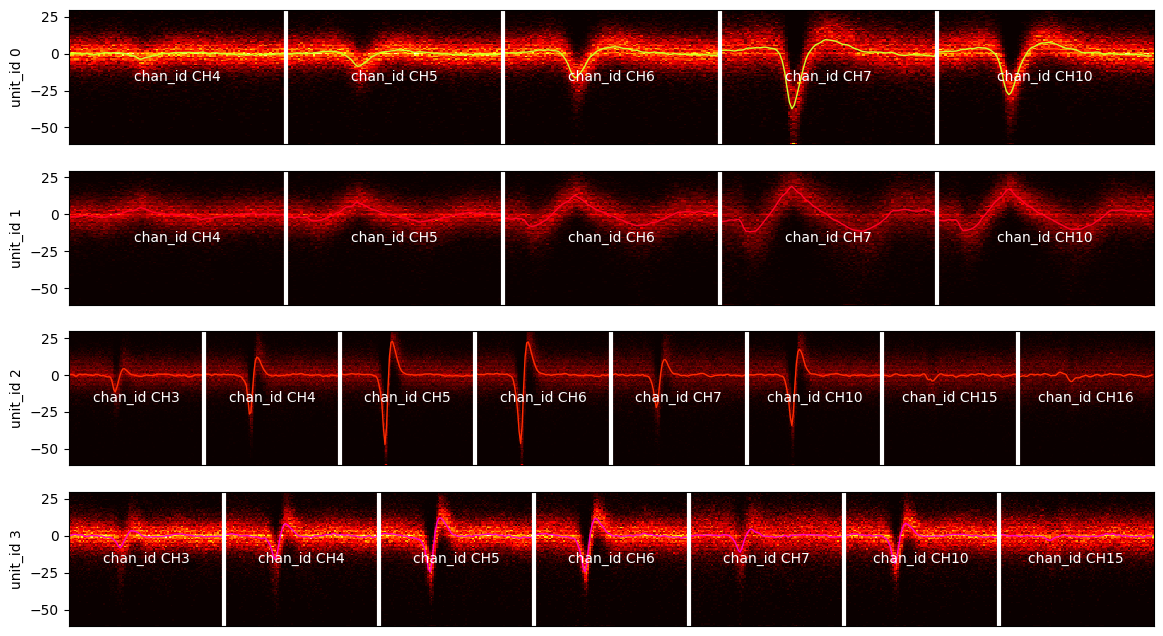

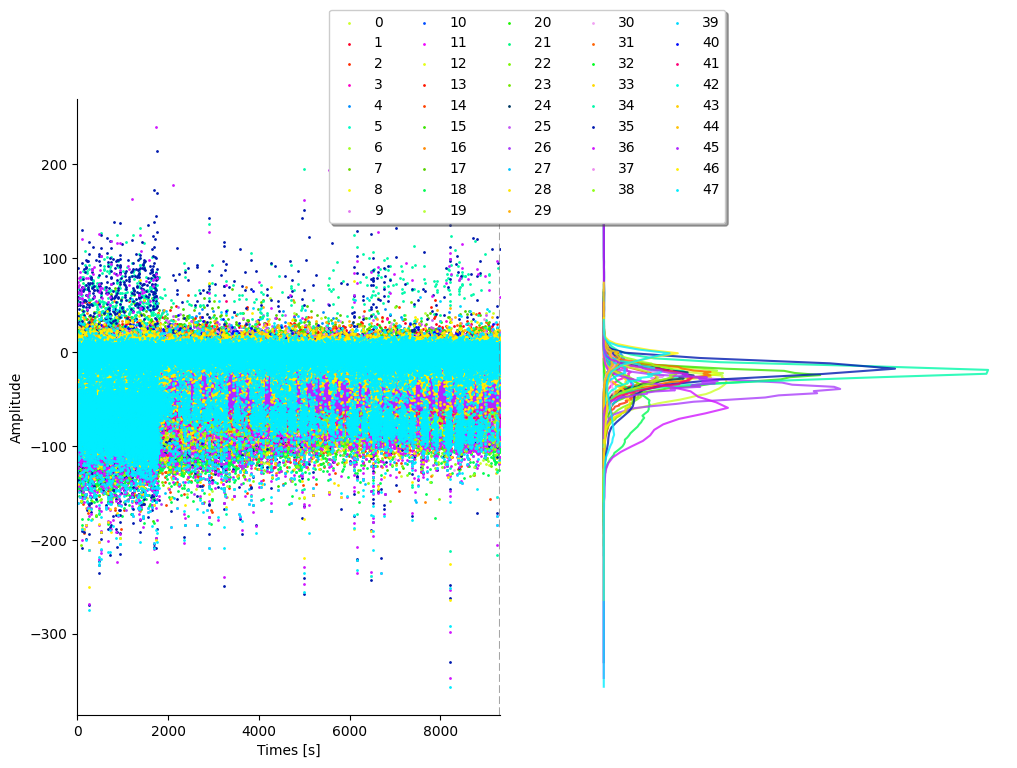

In [28]:
units = sorting_TDC.unit_ids
units = units[:4]
sw.plot_unit_waveforms(analyzer_TDC, unit_ids=units, figsize=(16,4))
sw.plot_unit_templates(analyzer_TDC, unit_ids=units, figsize=(16,4))
sw.plot_unit_locations(analyzer_TDC, unit_ids=units, figsize=(16,4))
sw.plot_unit_waveforms_density_map(analyzer_TDC, unit_ids=units, figsize=(14, 8))
sw.plot_amplitudes(analyzer_TDC, plot_histograms=True, figsize=(12, 8))

In [29]:
import os

curr_path = oe_path

recordnode_folder = 'Record Node 101'
experiment_folder = 'experiment1'
recording_folder = 'recording3'
curr_path = os.path.join(oe_path, recordnode_folder, experiment_folder, recording_folder)

sync_messages_path = os.path.join(curr_path, 'sync_messages.txt')
print(f'Sync Messages Filepath: {sync_messages_path}')

try:
    with open(sync_messages_path, 'r') as f:
        for line in f:
            line=line.split(" ")
            start_time = int(line[-1])
except FileNotFoundError:
    print(f"Error: start time_path={sync_messages_path} not found at {sync_messages_path}")
except Exception as e:
    print(f"An error occurred while reading start time: {e}")

print(f'\nStart Time: {start_time}')
recording_start_time = start_time

Sync Messages Filepath: C:\Users\tmerri03\Desktop\Neural Data\60 Trial Data (click no puff)\unfiltered data\Record Node 101\experiment1\recording3\sync_messages.txt

Start Time: 136204200


In [30]:
from open_ephys.analysis import Session

session = Session(oe_path)
recording = session.recordnodes[0].recordings[0]
sample_time = ((recording.events.sample_number) - int(recording_start_time))/30000
sample_time = sample_time[2:]#fix for this recording specifically

In [31]:
diffs = np.diff(sample_time)
mask = (diffs > 0.15) & (diffs < 6)  #filter between 0.15 and 5 seconds
start_time = sample_time[:-1][mask].reset_index(drop=True)
end_time = sample_time[1:][mask].reset_index(drop=True)
durations = diffs[mask]

# ---- and put them all into a dataframe ----
stimuli_arr = pd.DataFrame(columns=['Start Time', 'End Time', 'Duration', 'Stimuli Type'])
stimuli_arr['Start Time'] = start_time
stimuli_arr['End Time'] = end_time
stimuli_arr['Duration'] = durations
stimuli_arr['Start Time'] = stimuli_arr['Start Time'] - 0.5
stimuli_arr['End Time'] = stimuli_arr['End Time'] + 0.5
log_path = r"R:\Data\RhythmPerception\MBL\NCM\07242025\g53o49_NCM_puff(click-noair)_ProbeH4_2025-07-24_14-53-31_site1\Filtered\playback_log_20230412_110019.csv"
log_file = pd.read_csv(log_path)
song_order = log_file['Song']
stimuli_arr['Stimuli Type'] = song_order
stimuli_arr = stimuli_arr[stimuli_arr['Stimuli Type'] == 'Rule_2100reg.wav'].reset_index(drop=True)

In [32]:
spike_times = np.load(
    os.path.join(sorting_out_folder, 'sorter_output', 'spike_times.npy')).astype(
    int)

spike_clusters = np.load(
    os.path.join(sorting_out_folder, 'sorter_output', 'spike_clusters.npy')).astype(
    int)

spike_times = (spike_times) / 30000

In [47]:
# analyzer_TDC.compute("quality_metrics")

if not analyzer_TDC.has_extension("templates"):
    analyzer_TDC.compute("templates")

if not analyzer_TDC.has_extension("isi_histograms"):
    analyzer_TDC.compute("isi_histograms")

if not analyzer_TDC.has_extension("spike_amplitudes"):
    analyzer_TDC.compute("spike_amplitudes")

sqm.compute_quality_metrics(
    analyzer_TDC,
    metric_names=[
        "snr",
        "firing_rate",
        "isi_violations",
        "presence_ratio",
    ],
    qm_params={"refractory_period_ms": 1}  # optional cutoff for isi_violations
)

KeyError: 'isi_violations'

In [36]:
qm = analyzer_TDC.get_extension("quality_metrics").get_data()

In [ ]:
clusters = pd.unique(spike_clusters)
for c, cluster in enumerate(clusters):
    if qm.loc[c, 'isi_violations_count']/qm.loc[c, 'num_spikes']*100<1:
        spike_times_loc = spike_times[spike_clusters == cluster]

        fig, ax = plt.subplots(figsize=(10,5))
        for r, row in stimuli_arr.iterrows():
            mask = (spike_times_loc > row['Start Time']) & (spike_times_loc < row['End Time'])
            trial_spks = spike_times_loc[mask] - row['Start Time']

            ax.vlines(trial_spks, ymin=r, ymax=r+0.5)
        ax.set_title(f'Cluster {cluster}')
        plt.show()